# Logistic Regression for SUV Purchase Prediction

Logistic regression will be used to predict whether a customer will purchase an SUV based on demographic and financial data. By analyzing key factors such as age, gender, and estimated salary, this analysis aims to identify significant predictors of SUV purchase behavior. The goal is to assess the model’s accuracy in predicting customer decisions and provide insights into factors influencing SUV purchases.

In [1]:
# Import Necessary Libraries
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.linear_model import LogisticRegression
from scipy.special import expit as logistic_sigmoid
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.stats import multivariate_normal, bernoulli, beta, norm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.metrics import log_loss
from sklearn.datasets import load_iris

## 0) Exploring Data

1. Load the Data

In [2]:
# Load the dataset
df = pd.read_csv('suv_data.csv')

# Display the first few rows of the dataset
print("Dataset Preview:")
print(df.head())

Dataset Preview:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [3]:
# Check dataset size
print (df.shape)

# check dataset structure
print(df.info())

(400, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


There is no missing value found.

##### Total Number of Customers:

In [4]:
print("Number of customers: ", len(df))

Number of customers:  400


#### Customer Who purchased the SUV

<Axes: xlabel='Purchased', ylabel='count'>

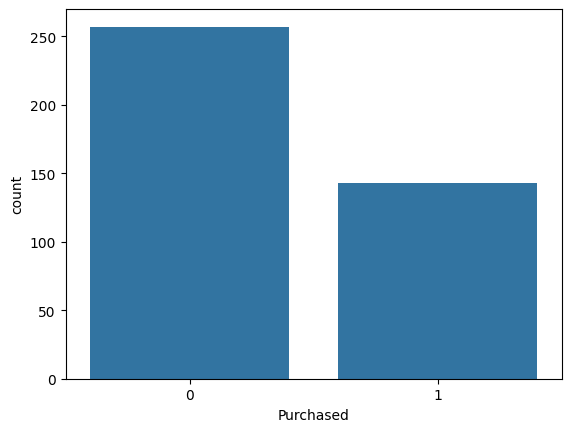

In [5]:
sns.countplot(x='Purchased', data = df)

#### Customer who purchased SUV based on Gender

<Axes: xlabel='Purchased', ylabel='count'>

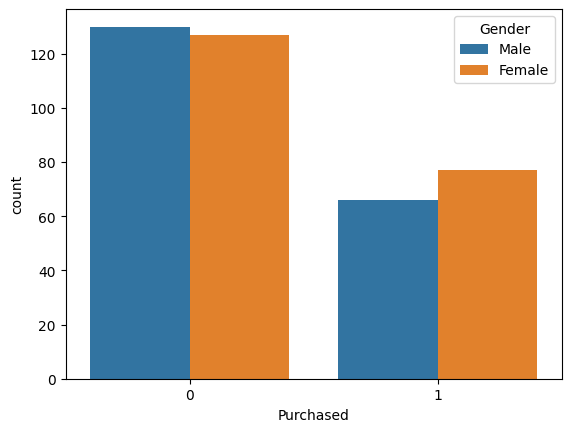

In [6]:
sns.countplot(x='Purchased', hue = 'Gender', data = df)

#### Age distribution of customers

<Axes: ylabel='Frequency'>

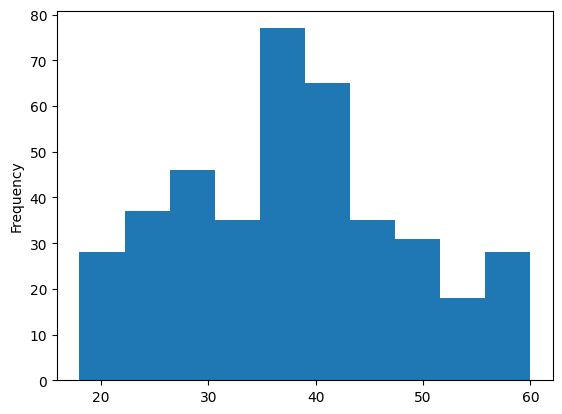

In [7]:
df['Age'].plot.hist()

#### Estimated Salary Distribution

<Axes: ylabel='Frequency'>

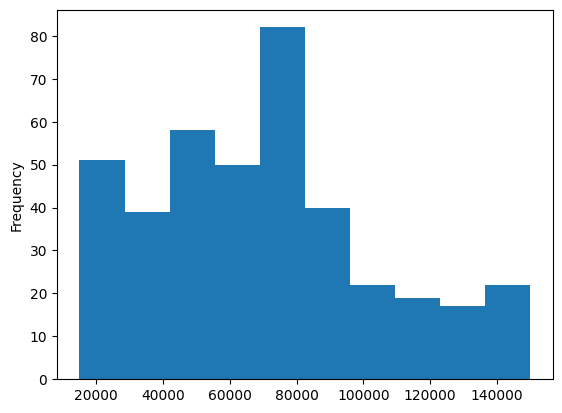

In [8]:
df['EstimatedSalary'].plot.hist()

## 1) Pre-processing Data

1. Check for missing values

In [9]:
# Check for missing values
print("\nMissing Values in Each Column:")
print(df.isnull().sum())


Missing Values in Each Column:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


2. Clean the Dataset

In [10]:
# Drop rows with missing values (if any)
df = df.dropna()

# Verify the cleaned dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


3. Encode Categorical Variable (Gender)

In [11]:
# Create dummy variables for the 'Gender' column
Gender = pd.get_dummies(df['Gender'], drop_first=True)  # Male -> 1, Female -> 0

# Add the dummy variable back to the DataFrame as 'Gender' and cast to integers
df['Gender'] = Gender.astype(int)

# Confirm the encoding
print("\nGender Encoding Check:")
print("First 10 values in the Gender column:")
print(df['Gender'].head(10))


Gender Encoding Check:
First 10 values in the Gender column:
0    1
1    1
2    0
3    0
4    1
5    1
6    0
7    0
8    1
9    0
Name: Gender, dtype: int64


In [12]:
# Count the number of males and females
num_males = df['Gender'].sum()  # Since Male is encoded as 1, sum gives the count of males
num_females = len(df) - num_males  # Total rows - males = females

# Display the counts
print("\nGender Count:")
print(f"Number of Males: {num_males}")
print(f"Number of Females: {num_females}")


Gender Count:
Number of Males: 196
Number of Females: 204


## 2) Define Covariates (X) and Target (Y)


In [13]:
# Define the outcome variable and covariates
y = df['Purchased']  # Target: Purchased or not (binary)
X = df[['Age', 'EstimatedSalary', 'Gender']]  # Covariates: Age, Salary, Gender

# Add an intercept column for the model
X['intercept'] = 1

/var/folders/rf/c4wm9pq50j3bjhbyfct63d2h0000gn/T/ipykernel_75989/1353071010.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['intercept'] = 1


### Correlation Matrix

In [14]:
# Concatenate y and X for correlation analysis
YX = pd.concat([y, X], axis=1)

# Compute the correlation matrix
correlation_matrix = YX.corr()
print(correlation_matrix)

                 Purchased       Age  EstimatedSalary    Gender  intercept
Purchased         1.000000  0.622454         0.362083 -0.042469        NaN
Age               0.622454  1.000000         0.155238 -0.073741        NaN
EstimatedSalary   0.362083  0.155238         1.000000 -0.060435        NaN
Gender           -0.042469 -0.073741        -0.060435  1.000000        NaN
intercept              NaN       NaN              NaN       NaN        NaN


1. **Target Variable (Purchased)**:
   - Strong positive correlation between age (0.622454) and SUV purchases
         - This suggests older people are more likely to purchase SUVs.
   
   - A moderate positive correlation with EstimatedSalary (0.362083)
         - This suggests higher salaries increase the likelyhood of SUV purchases.

   - Gender (-0.060435)
         - Correlation is close to zero, which suggests no significant relationship between gender and SUV purchases.

2. **Relationships among predictors**:
   - Age and EstimatedSalary (0.155238)
         - There is a slight tendency for higher salary with older age customers. 

## 3) Fitting the Homogenous Model 
- Baseline model that predicts probability of SUV purchases using intercept only. 

In [15]:
import statsmodels.api as sm

# Fit a homogeneous logistic regression model (intercept only)
X_homogeneous = X[['intercept']]
model_homogeneous = sm.Logit(y, X_homogeneous).fit()

# Display the summary
print("\nHomogeneous Model Summary:")
print(model_homogeneous.summary())

Optimization terminated successfully.
         Current function value: 0.651966
         Iterations 4

Homogeneous Model Summary:
                           Logit Regression Results                           
Dep. Variable:              Purchased   No. Observations:                  400
Model:                          Logit   Df Residuals:                      399
Method:                           MLE   Df Model:                            0
Date:                Thu, 05 Dec 2024   Pseudo R-squ.:               6.058e-11
Time:                        22:29:43   Log-Likelihood:                -260.79
converged:                       True   LL-Null:                       -260.79
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.5862      0.104     -5.619      0.000      -0.791      -0.382


1. **Negative Intercept Coefficient (-0.5862)**:
   - This indicates that the log-odds of purchasing an SUV are below zero.
         - meaning the probability of purchase is less that 60% on average. 
   
2. **The Log-Likelihood (-260.79) and Pseudo R-squared (6.058e-11)**:
   - This indicates that this model does not explain any variability in the data beyong the baseline probability. 

## 4) Fitting the Heterogenous Model

In [16]:
# Fit a heterogeneous logistic regression model (all predictors)
X_heterogeneous = X[['intercept', 'Age', 'EstimatedSalary', 'Gender']]
model_heterogeneous = sm.Logit(y, X_heterogeneous).fit()

# Display the summary
print("\nHeterogeneous Model Summary:")
print(model_heterogeneous.summary())

Optimization terminated successfully.
         Current function value: 0.344804
         Iterations 8

Heterogeneous Model Summary:
                           Logit Regression Results                           
Dep. Variable:              Purchased   No. Observations:                  400
Model:                          Logit   Df Residuals:                      396
Method:                           MLE   Df Model:                            3
Date:                Thu, 05 Dec 2024   Pseudo R-squ.:                  0.4711
Time:                        22:29:43   Log-Likelihood:                -137.92
converged:                       True   LL-Null:                       -260.79
Covariance Type:            nonrobust   LLR p-value:                 5.488e-53
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
intercept         -12.7836      1.359     -9.405      0.000     -15.

1. **Coefficients**:
   - Intercept (-12.7836)
         - The baseline log-odds of purchasing an SUV when all predictors are at zero is very low.
   - Age (0.2370): positive and significant (p<0.05)
         - As age increases, the likelyhood of purchasing an SUV rises.
   - EstimatedSalary (3.644e-05): positive and significant (p<0.05)
         - Higher salary increases the probability of purchasing an SUV
   - Gender (0.3338): (p=0.274)
         - Gender does not have a significant impact on SUV purchase likelihood. 

2. **The Log-Likelihood (-137.92) and Pseudo R-squared (0.4711)**:
   - The heterogeneous model improves prediction accuracy by incorporating key predictors like age and salary.

## 5) Simulate Posterior Distribution of Coefficients 

In [17]:
# Extract the coefficients (betas) and covariance matrix from the heterogeneous model
beta_mean = model_heterogeneous.params
beta_cov = model_heterogeneous.cov_params()

# Simulate 1000 samples from the posterior distribution
n = 1000
simulated_betas = np.random.multivariate_normal(beta_mean, beta_cov, size=n)

# Display the first few rows of the simulated coefficients
print("\nSimulated Posterior Coefficients:")
print(pd.DataFrame(simulated_betas, columns=beta_mean.index).head())


Simulated Posterior Coefficients:
   intercept       Age  EstimatedSalary    Gender
0 -12.944141  0.245908         0.000038  0.322443
1 -13.281573  0.246223         0.000039  0.262223
2 -13.228787  0.239031         0.000039  0.702027
3 -14.693154  0.273877         0.000042  0.550991
4 -10.384198  0.191210         0.000030  0.284029


1. **Intercept**
- Consistently negative

2. **Age**
- Consistently positive, indicating certainty in positive effect on SUV purchase.

3. **EstimatedSalary**
- Nearly zero but slightly positive, indicating certainty in its small positive impact.

4. **Gender**
- Positive but varies big, suggesting Gender's limited influence on SUV purchase.

## 6) Plot Simulated Coefficient Distribution
- Histogram for the simulated coefficients to assess uncertainty.

intercept:
Mean: -12.778383606947115
Standard Deviation: 1.3791709669443584
P(beta>0): 0.0
Age:
Mean: 0.2371767216133002
Standard Deviation: 0.026338850685674528
P(beta>0): 1.0
EstimatedSalary:
Mean: 3.623672512885373e-05
Standard Deviation: 5.659542184480351e-06
P(beta>0): 1.0
Gender:
Mean: 0.34617995869181073
Standard Deviation: 0.3059464293963683
P(beta>0): 0.863


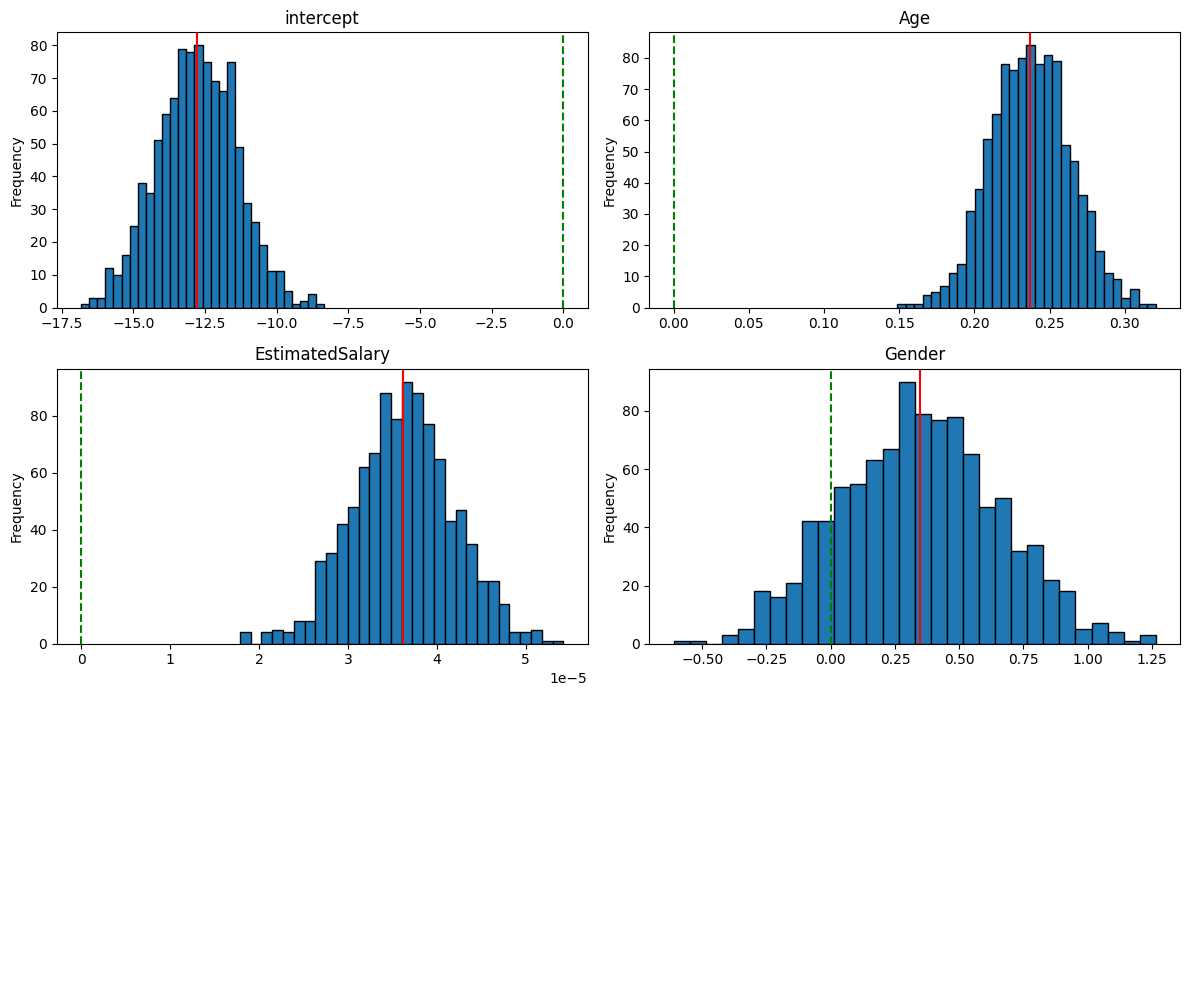

In [18]:
# Calculate summary statistics
b_mean = np.mean(simulated_betas, axis=0)
b_std = np.std(simulated_betas, axis=0)
b_pos = np.mean(simulated_betas > 0, axis=0)

# Print summary statistics
for i, coef in enumerate(beta_mean.index):
    print(f'{coef}:')
    print(f'Mean: {b_mean[i]}')
    print(f'Standard Deviation: {b_std[i]}')
    print(f'P(beta>0): {b_pos[i]}')

# Plot the results
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, coef in enumerate(beta_mean.index):
    if i >= len(axes):  # Stop plotting if we've used up all axes
        break
    axes[i].hist(simulated_betas[:, i], bins=30, edgecolor='black')
    axes[i].axvline(b_mean[i], color='red')
    axes[i].axvline(0, color='green', linestyle='--')
    axes[i].set_title(coef)
    axes[i].set_ylabel('Frequency')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Age and EstimatedSalary are the most consistent and impactful predictors of SUV purchase with 100% probability of being greater than zero. 
- Low standard deviations suggest consistent certainty in it positive influence on SUV purchase. 

## 7) Make Prediction for an Average Individual
- Average individual accounts the mean values of all covariates (age, salary, gender)

In [19]:
# Define the average individual
average_X = X_heterogeneous.mean()

# Calculate predicted probabilities for the average individual
predicted_probs = logistic_sigmoid(np.dot(simulated_betas, average_X))

# Display the predicted probabilities
print("\nPredicted Probabilities for an Average Individual:")
print(f"Median: {np.median(predicted_probs):.3f}")
print(f"95% CI: [{np.percentile(predicted_probs, 2.5):.3f}, {np.percentile(predicted_probs, 97.5):.3f}]")


Predicted Probabilities for an Average Individual:
Median: 0.239
95% CI: [0.183, 0.303]


- Average individual has a 23.9% likelihood of purchasing an SUV based on the model prediction. 
- The model is 95% confident that true probability of purchase for an average individuals likes between 18.3% and 30.3%.

## 8) Simulate Outcomes for the Average Individual

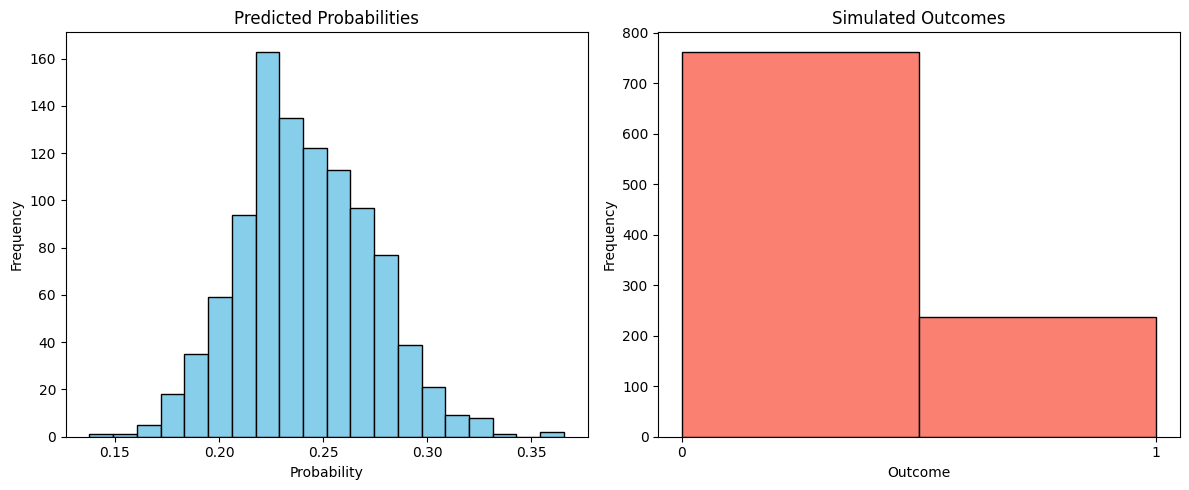

In [20]:
# Simulate outcomes using the predicted probabilities
simulated_outcomes = bernoulli.rvs(predicted_probs)

# Plot the predicted probabilities and simulated outcomes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of predicted probabilities
axes[0].hist(predicted_probs, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Predicted Probabilities')
axes[0].set_xlabel('Probability')
axes[0].set_ylabel('Frequency')

# Histogram of simulated outcomes
axes[1].hist(simulated_outcomes, bins=2, color='salmon', edgecolor='black')
axes[1].set_title('Simulated Outcomes')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['0', '1'])

plt.tight_layout()
plt.show()

1. **Predicted Probabilities**
- Most probabilities cluster between 0.2 ~ 0.3, indicating a generally low likelihood of purchasing SUV.

2. **Simulated Outcomes**: 1(Purchase) and 0(No purchase)
- Majority of outcomes are 0, while smaller portion is 1. 
- The result aligns with the low probabilities observed. 

## 9) Compare Homogenous and Heterogenous Models
- AIC evaluates and compare the goodness of fit of statistical models.
- Lower AIC values indicate a better trade-off between fit and simplicity. 

In [21]:
# Compare the AIC of the two models
aic_homogeneous = model_homogeneous.aic
aic_heterogeneous = model_heterogeneous.aic

print("\nModel Comparison:")
print(f"Homogeneous Model AIC: {model_homogeneous.aic}")
print(f"Heterogeneous Model AIC: {model_heterogeneous.aic}")

# Interpret the results
if aic_heterogeneous < aic_homogeneous:
    print("\nThe Heterogeneous model provides a better fit to the data based on AIC.")
else:
    print("\nThe Homogeneous model provides a better fit to the data based on AIC.")


Model Comparison:
Homogeneous Model AIC: 523.5729657959091
Heterogeneous Model AIC: 283.84322537592294

The Heterogeneous model provides a better fit to the data based on AIC.


In [22]:
from sklearn.metrics import accuracy_score

# Predictions for Homogeneous Model
y_pred_homogeneous_prob = model_homogeneous.predict(X_homogeneous)
y_pred_homogeneous = (y_pred_homogeneous_prob >= 0.5).astype(int)

# Predictions for Heterogeneous Model
y_pred_heterogeneous_prob = model_heterogeneous.predict(X_heterogeneous)
y_pred_heterogeneous = (y_pred_heterogeneous_prob >= 0.5).astype(int)

# Calculate accuracy scores
accuracy_homogeneous = accuracy_score(y, y_pred_homogeneous)
accuracy_heterogeneous = accuracy_score(y, y_pred_heterogeneous)

# Print accuracy results
print("\nModel Accuracy Comparison:")
print(f"Homogeneous Model Accuracy Score: {accuracy_homogeneous:.3f}")
print(f"Heterogeneous Model Accuracy Score: {accuracy_heterogeneous:.3f}")

# Interpret accuracy results
if accuracy_heterogeneous > accuracy_homogeneous:
    print("\nThe Heterogeneous model has a higher accuracy score.")
else:
    print("\nThe Homogeneous model has a higher accuracy score.")



Model Accuracy Comparison:
Homogeneous Model Accuracy Score: 0.642
Heterogeneous Model Accuracy Score: 0.853

The Heterogeneous model has a higher accuracy score.
